
====== Logistic Regression ======
Accuracy:  0.8171
Precision: 0.8615
Recall:    0.7814
F1 Score:  0.8195

====== Naive Bayes ======
Accuracy:  0.8198
Precision: 0.8683
Recall:    0.7789
F1 Score:  0.8212

====== Decision Tree ======
Accuracy:  0.9573
Precision: 0.9668
Recall:    0.9523
F1 Score:  0.9595

====== KNN ======
Accuracy:  0.9533
Precision: 0.9481
Recall:    0.9648
F1 Score:  0.9564



====== SVM (RBF) ======
Accuracy:  0.8838
Precision: 0.9560
Recall:    0.8191
F1 Score:  0.8823

====== Random Forest ======
Accuracy:  0.9559
Precision: 0.9620
Recall:    0.9548
F1 Score:  0.9584

====== Histogram Gradient Boosting ======
Accuracy:  0.9586
Precision: 0.9553
Recall:    0.9673
F1 Score:  0.9613

Saved results to results_classical_reduced.csv


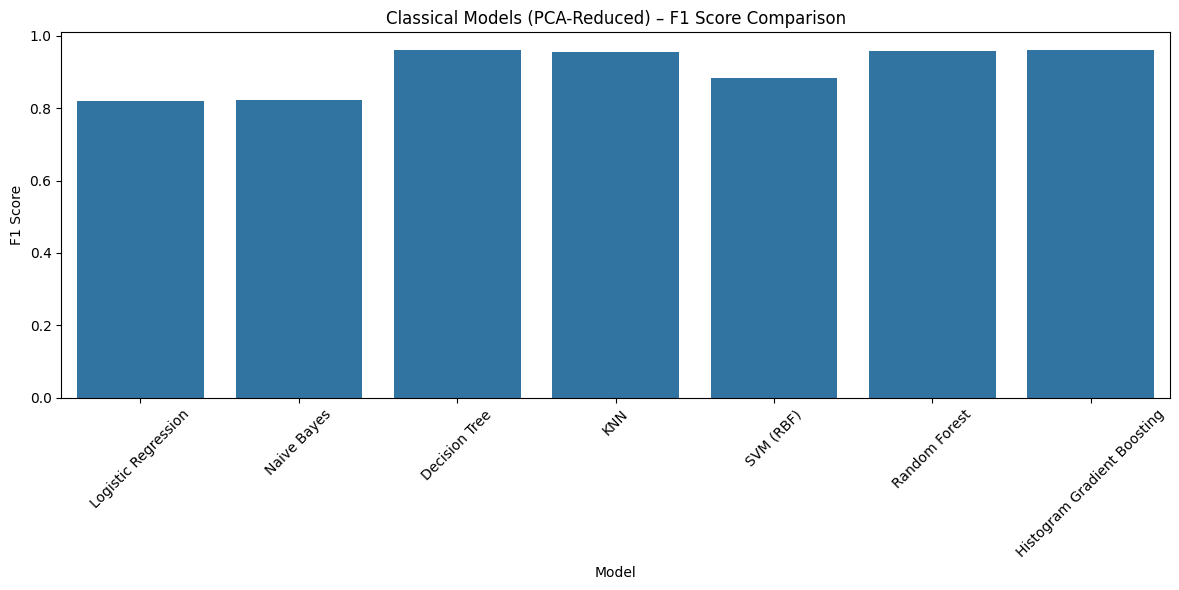

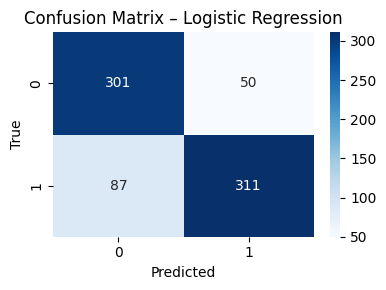

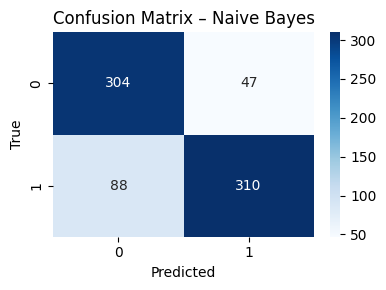

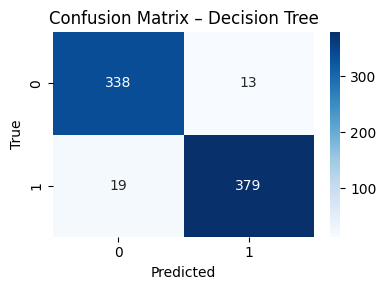

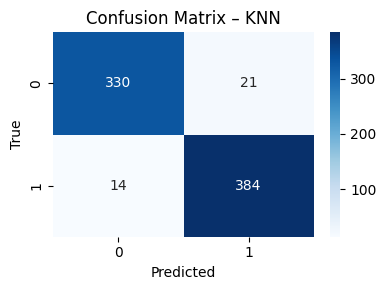

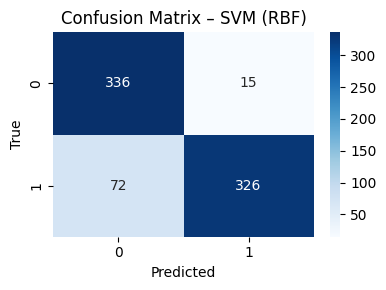

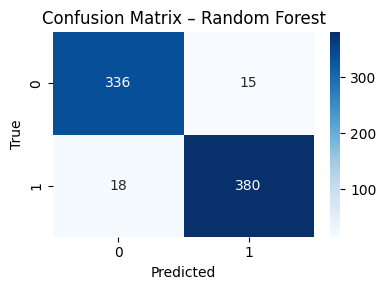

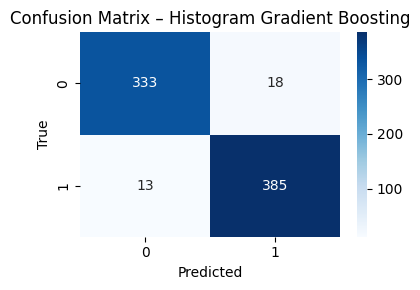

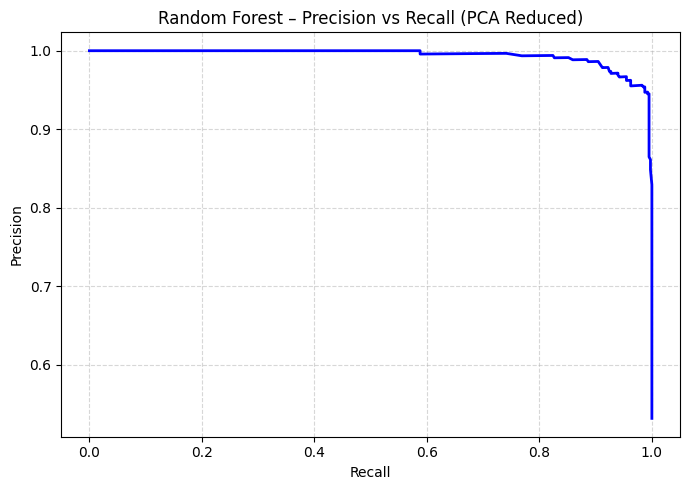

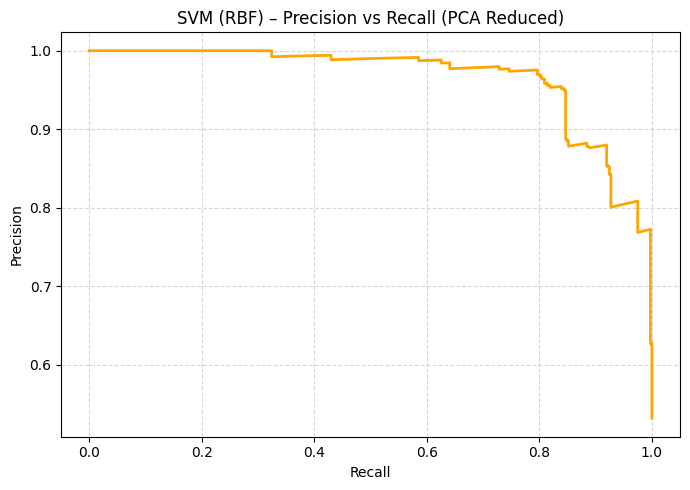

In [ ]:
# ============================================================
# Classical ML Models on PCA-Reduced Dataset (n_components=4)
# Models: LR, NB, DT, KNN, SVM, RF, HGBC
# Dataset: data/data.csv
# Metrics: Accuracy, Precision, Recall, F1
# Saves Results: results_classical_reduced.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import precision_recall_curve

import warnings
warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 1. Load Dataset
# ------------------------------------------------------------
df = pd.read_csv("data/data.csv")

# Target
target_col = "ASD_traits"

# Identify categorical columns
categorical_cols = ["Sex", "Ethnicity", "Jaundice", "Family_mem_with_ASD", "Who_completed_the_test"]

# ------------------------------------------------------------
# 2. Encode categorical columns
# ------------------------------------------------------------
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Encode target as well
df[target_col] = LabelEncoder().fit_transform(df[target_col])  # Yes/No → 1/0

# ------------------------------------------------------------
# 3. Train-test split
# ------------------------------------------------------------
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ------------------------------------------------------------
# 4. Scaling
# ------------------------------------------------------------
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 5. PCA (4 Components)
# ------------------------------------------------------------
pca = PCA(n_components=4, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# ------------------------------------------------------------
# 6. Define all classical models
# ------------------------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF)": SVC(kernel="rbf", probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
}

results = []

# ------------------------------------------------------------
# 7. Train & Evaluate all models
# ------------------------------------------------------------
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])
    print(f"\n====== {name} ======")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")

# ------------------------------------------------------------
# 8. Save results as CSV
# ------------------------------------------------------------
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)
results_df.to_csv("results_classical_reduced.csv", index=False)

print("\nSaved results to results_classical_reduced.csv")

# ------------------------------------------------------------
# 9. Plot performance comparison
# ------------------------------------------------------------
plt.figure(figsize=(12, 6))
sns.barplot(data=results_df, x="Model", y="F1 Score")
plt.title("Classical Models (PCA-Reduced) – F1 Score Comparison")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Confusion Matrix for each model
# ------------------------------------------------------------
for name, model in models.items():
    y_pred = model.predict(X_test_pca)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()


# ----- Random Forest -----
rf_proba = rf_model.predict_proba(X_test_pca)[:, 1]
rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(7, 5))
plt.plot(rf_recall, rf_precision, linewidth=2, color='orange', label='Precision')
# For visualization, show recall as a line on same y-axis
plt.plot(rf_recall, rf_recall, linewidth=2, color='violet', linestyle='--', label='Recall')
plt.title("Random Forest – Precision vs Recall (PCA Reduced)")
plt.xlabel("Recall (x-axis)")
plt.ylabel("Value (y-axis)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("rf_precision_recall_curve_pca_colored.png", dpi=300)
plt.show()

# ----- SVM (RBF) -----
svm_scores = svm_model.decision_function(X_test_pca)
svm_precision, svm_recall, _ = precision_recall_curve(y_test, svm_scores)

plt.figure(figsize=(7, 5))
plt.plot(svm_recall, svm_precision, linewidth=2, color='orange', label='Precision')
plt.plot(svm_recall, svm_recall, linewidth=2, color='violet', linestyle='--', label='Recall')
plt.title("SVM (RBF) – Precision vs Recall (PCA Reduced)")
plt.xlabel("Recall (x-axis)")
plt.ylabel("Value (y-axis)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("svm_precision_recall_curve_pca_colored.png", dpi=300)
plt.show()

In [9]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Make sure you are using the trained model objects:
rf_model = models["Random Forest"]
svm_model = models["SVM (RBF)"]

# ---------------- RF ----------------
# Random Forest predicted probabilities
rf_proba = rf_model.predict_proba(X_test_pca)[:, 1]

rf_precision, rf_recall, _ = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(7,5))
plt.plot(rf_recall, rf_precision, linewidth=2)
plt.title("Random Forest – Precision vs Recall Curve (PCA Reduced)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("rf_precision_recall_curve_pca.png", dpi=300)
plt.show()

# ---------------- SVM ----------------
# SVM decision scores for PR curve
svm_scores = svm_model.decision_function(X_test_pca)

svm_precision, svm_recall, _ = precision_recall_curve(y_test, svm_scores)

plt.figure(figsize=(7,5))
plt.plot(svm_recall, svm_precision, linewidth=2, color='orange')
plt.title("SVM (RBF) – Precision vs Recall Curve (PCA Reduced)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("svm_precision_recall_curve_pca.png", dpi=300)
plt.show()


TypeError: list indices must be integers or slices, not str

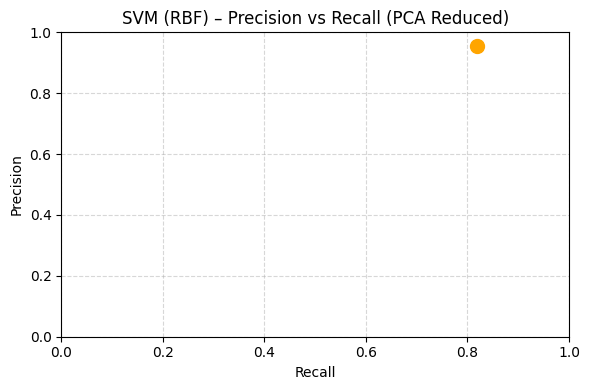

In [7]:
# ================================
# Precision vs Recall – SVM (RBF)
# ================================

svm_prec = results_df.loc[results_df["Model"] == "SVM (RBF)", "Precision"].values[0]
svm_rec  = results_df.loc[results_df["Model"] == "SVM (RBF)", "Recall"].values[0]

plt.figure(figsize=(6, 4))
plt.plot([svm_rec], [svm_prec], marker='o', markersize=10, color='orange')
plt.title("SVM (RBF) – Precision vs Recall (PCA Reduced)")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("svm_precision_vs_recall_pca.png", dpi=300)
plt.show()
